In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# U-Net: version 1 without adding noise

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/kn445/.netrc.


1134
1134
1134
1134
1134
1134
1134
1134
1134
1134
[0.035374440252780914, 0.07303979247808456, 0.03316425159573555, 0.04774923622608185, 0.024296384304761887, 0.029650988057255745, 0.048808030784130096, 0.03878834843635559, 0.02650352194905281, 0.03304304927587509]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


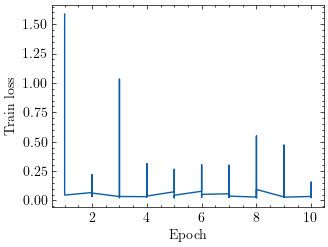

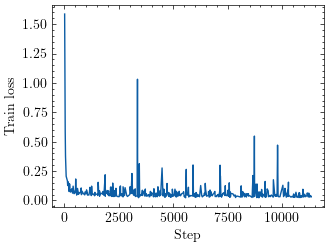

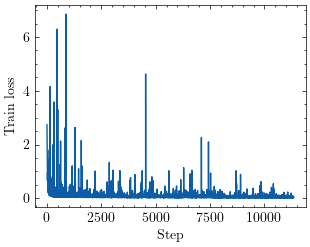

In [2]:
plt.style.use(['science'])

api = wandb.Api()
run = api.run("/nobonobonobok-university-of-cambridge/U-Net/runs/89hv2h3e")

full_history = run.scan_history()
losses = [row['train loss'] for row in full_history]
steps = [row['step'] for row in full_history]
epochs = [row['epoch'] for row in full_history]

last_indexes = []
for k in range(1, epochs[-1]+1):
  epochs_indexes = [i for i, j in enumerate(epochs) if j==k]
  last_indexes.append(epochs_indexes[-1])
  print(len(epochs_indexes))

losses_af_e_epoch = [losses[i] for i in last_indexes]
epochs_af_e_epoch = [epochs[i] for i in last_indexes]

print(losses_af_e_epoch)
print(epochs_af_e_epoch)

run.history().plot(x='epoch', y='train loss', legend=False)
plt.ylabel('Train loss')
plt.xlabel('Epoch')
plt.show()

run.history().plot(x='step', y='train loss', legend=False)
plt.ylabel('Train loss')
plt.xlabel('Step')
plt.show()

plt.plot(steps, losses)
plt.ylabel('Train loss')
plt.xlabel('Step')
plt.show()

# U-Net v2

DataFrame (500 points sampled)
     _step  epoch    _runtime    _timestamp  train loss   step
0        7      1   18.128840  1.787719e+09    1.664490      8
1       33      1   18.488457  1.787719e+09    0.608078     34
2       47      1   18.680066  1.787719e+09    0.369702     48
3       74      1   19.051606  1.787719e+09    0.171409     75
4       77      1   19.093192  1.787719e+09    0.219098     78
..     ...    ...         ...           ...         ...    ...
495  11231     10  382.747832  1.787719e+09    0.024766  11232
496  11251     10  383.029367  1.787719e+09    0.063036  11252
497  11264     10  383.213504  1.787719e+09    0.032974  11265
498  11324     10  387.727179  1.787719e+09    0.028977  11325
499  11329     10  387.797118  1.787719e+09    0.033020  11330

[500 rows x 6 columns]
1133
2267
3401
4535
5669
6803
7937
9071
10205
11339
final loss 0.03076469898223877


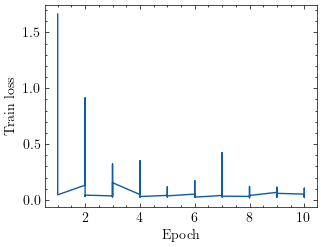

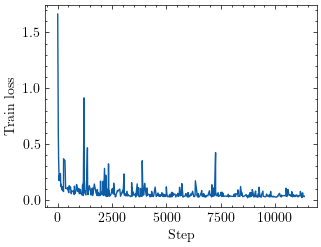

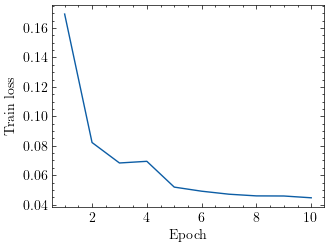

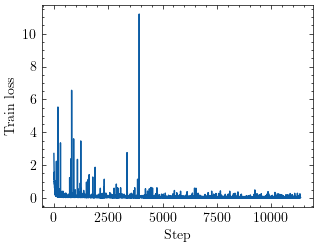

In [5]:
api = wandb.Api()
run = api.run("/nobonobonobok-university-of-cambridge/U-Net/runs/1s6mt9oo")

print('DataFrame (500 points sampled)')
print(run.history())

full_history = run.scan_history()
losses = [row['train loss'] for row in full_history]
steps = [row['step'] for row in full_history]
epochs = [row['epoch'] for row in full_history]

loss_averages = []
for k in range(1, epochs[-1]+1):
  epochs_indexes = [i for i, j in enumerate(epochs) if j==k]
  loss_averages.append(np.mean([losses[i] for i in epochs_indexes]))
  print(epochs_indexes[-1])
  # print(len(epochs_indexes))

losses_af_e_epoch = [losses[i] for i in last_indexes]
epochs_af_e_epoch = [epochs[i] for i in last_indexes]

# print(losses_af_e_epoch)
# print(epochs_af_e_epoch)
print('final loss', losses[-1])


run.history().plot(x='epoch', y='train loss', legend=False)
plt.ylabel('Train loss')
plt.xlabel('Epoch')
# plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/unet_without_noise_v2_loss_epoch.png')
plt.show()

run.history().plot(x='step', y='train loss', legend=False)
plt.ylabel('Train loss')
plt.xlabel('Step')
# plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/unet_without_noise_v2_loss_step.png')
plt.show()

plt.plot(range(1, epochs[-1]+1), loss_averages)
plt.ylabel('Train loss')
plt.xlabel('Epoch')
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/unet_without_noise_v2_loss_epoch_updated.png')
plt.show()

plt.plot(steps, losses)
plt.ylabel('Train loss')
plt.xlabel('Step')
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/unet_without_noise_v2_loss_step_updated.png')
plt.show()

# ResNet

     _timestamp    loss  _step      _runtime
0  1.787703e+09  0.3357      0   1165.051630
1  1.787704e+09  0.1475      1   2133.085353
2  1.787705e+09  0.1156      2   3103.800735
3  1.787706e+09  0.0957      3   4084.544068
4  1.787707e+09  0.0818      4   5111.567948
5  1.787708e+09  0.0702      5   6121.498052
6  1.787709e+09  0.0615      6   7148.210341
7  1.787710e+09  0.0528      7   8181.516457
8  1.787711e+09  0.0450      8   9212.680749
9  1.787713e+09  0.0379      9  10235.670058


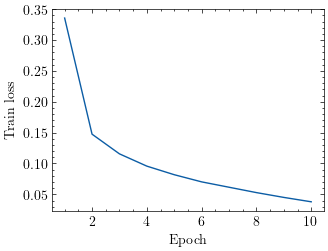

In [8]:
api = wandb.Api()
run = api.run("/nobonobonobok-university-of-cambridge/classifier/runs/xsti9ctg")
print(run.history())
losses = np.array(run.history()['loss'])
epochs = np.array(run.history()['_step'])+1
# print(losses, epochs)

plt.plot(epochs, losses)
plt.ylabel('Train loss')
plt.xlabel('Epoch')
# plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/resnet_loss.png')
plt.show()


# Swin

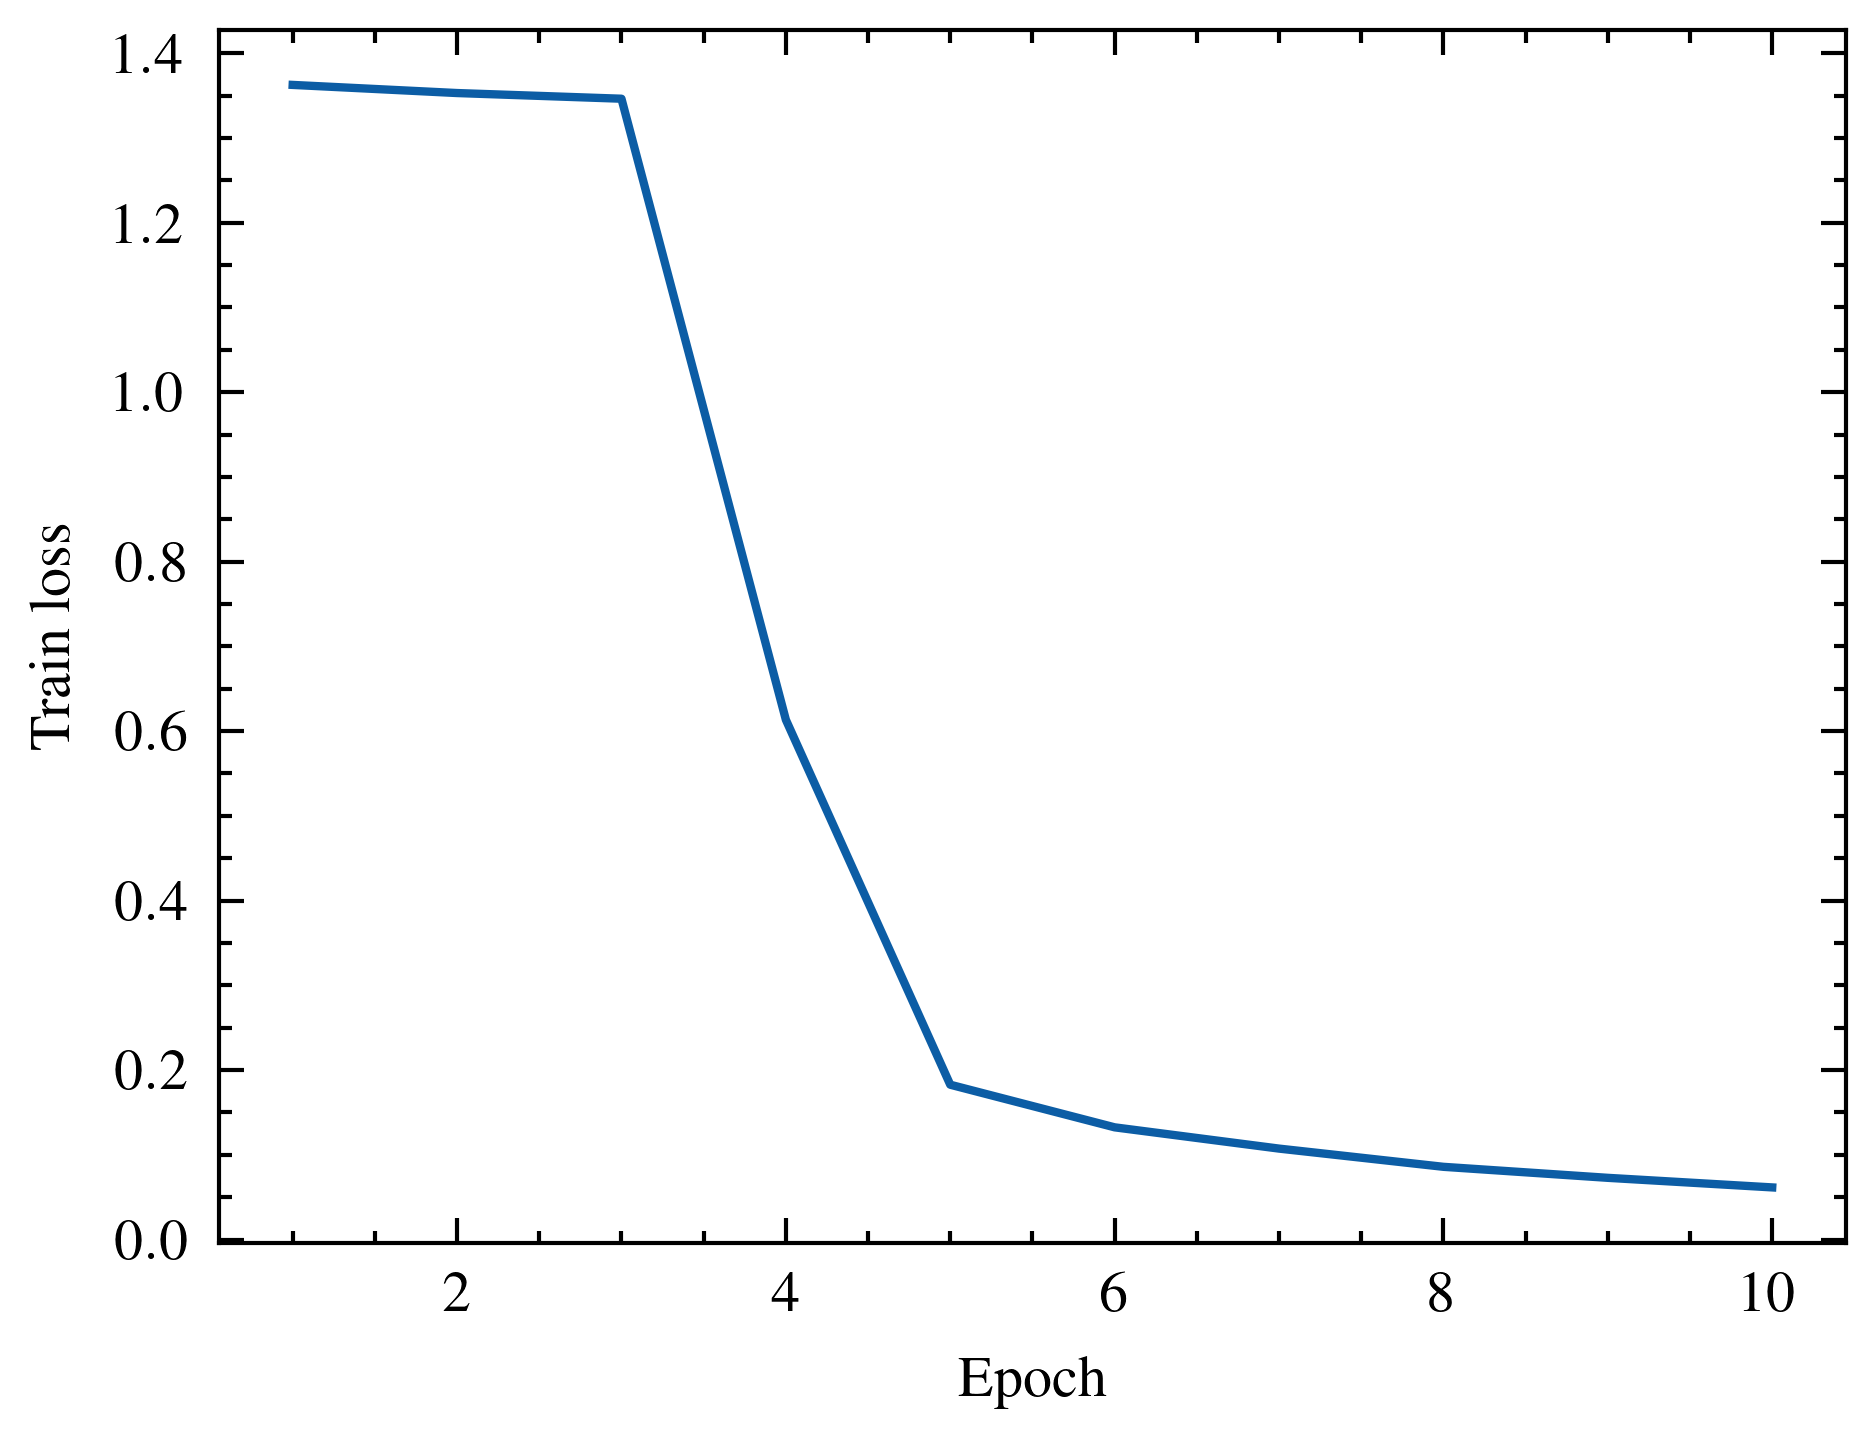

In [31]:
api = wandb.Api()
run = api.run("/nobonobonobok-university-of-cambridge/classifier/runs/ozl1g5ns")
# print(run.history())
losses = np.array(run.history()['loss'])
epochs = np.array(run.history()['_step'])+1
# print(losses, epochs)

plt.plot(epochs, losses)
plt.ylabel('Train loss')
plt.xlabel('Epoch')
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/swin_loss.png')
plt.show()